# Hotel Review Topic Modelling
## Pipeline: 

**Design decisions:**
- **Preprocessing**: City balanced stratified sample (~36,000 reviews, 30 hotels x 6 cities x 200 reviews each) using multilingual sentence embeddings (`paraphrase-multilingual-MiniLM-L12-v2`) and multilingual RoBERTa sentiment.
- **Topics**: 10 zero shot major topics.

**Pipeline overview:**
1. Stratified sampling (36k reviews, city balanced)
2. Text preprocessing and fragment splitting
3. Multilingual sentence embeddings
4. BERTopic with 10 zero shot major topics
5. Multilingual RoBERTa sentiment scoring

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import math
import re
import os
import scipy.cluster.hierarchy as sch
from scipy import stats

## 2. Stratified Hotel Sampling

In [3]:
# City Balanced Stratified Sampling
# 30 hotels x 6 cities x 200 reviews = ~36,000 reviews total.
# Saved on first run and reloaded automatically afterwards.
input_file  = "../Datasets/Hotel_Reviews.csv"
output_file = "../Datasets/Hotel_Reviews_StratSamp_Balanced.csv"

if os.path.exists(output_file):
    print(f"Stratified sample already exists — loading from {output_file}")
    df_sampled = pd.read_csv(output_file)
else:
    print("Building city-balanced stratified sample...")
    df = pd.read_csv(input_file)
    print(f"Full dataset : {len(df):,} reviews | {df['Hotel_Name'].nunique():,} hotels")

    def extract_city(address):
        if 'Netherlands' in address: return 'Amsterdam'
        elif 'United Kingdom' in address: return 'London'
        elif 'France' in address: return 'Paris'
        elif 'Spain' in address: return 'Barcelona'
        elif 'Italy' in address: return 'Milan'
        elif 'Austria' in address: return 'Vienna'
        else: return 'Other'

    df['City'] = df['Hotel_Address'].apply(extract_city)

    hotel_counts    = df.groupby('Hotel_Name').size()
    eligible_hotels = hotel_counts[hotel_counts >= 200].index
    df_eligible     = df[df['Hotel_Name'].isin(eligible_hotels)].copy()

    hotel_city_map_raw = df_eligible[['Hotel_Name', 'City']].drop_duplicates()
    print("Eligible Hotels per City:")
    print(hotel_city_map_raw['City'].value_counts())

    MAX_HOTELS_PER_CITY = 30
    balanced_hotels = hotel_city_map_raw.groupby('City').sample(
        n=MAX_HOTELS_PER_CITY, random_state=42
    )
    df_city_balanced = df_eligible.merge(balanced_hotels, on=['Hotel_Name', 'City'], how='inner')

    MAX_PER_HOTEL = 200
    df_sampled = (
        df_city_balanced
        .groupby(['Hotel_Name', 'City'])
        .sample(n=MAX_PER_HOTEL, random_state=42)
        .reset_index(drop=True)
    )
    df_sampled['ID'] = df_sampled.index
    df_sampled.to_csv(output_file, index=False)

    print(f"\n--- Final Balanced Dataset ---")
    print(f"Total Reviews : {len(df_sampled):,}")
    print(f"Hotels        : {df_sampled['Hotel_Name'].nunique()}")
    print(f"Cities        : {df_sampled['City'].nunique()}")

print(f"\nLoaded: {len(df_sampled):,} reviews | {df_sampled['Hotel_Name'].nunique()} hotels")

Stratified sample already exists — loading from ../Datasets/Hotel_Reviews_StratSamp_Balanced.csv

Loaded: 36,000 reviews | 180 hotels


## 3. Stop Words

To prevent the BERTopic model from creating uninformative clusters centred around widespread, dataset-specific terms (e.g. "hotel", "room", "stay"), the standard NLTK English stop words list was extended with custom domain-specific filler words. A random sample of 1,000 guest reviews was processed using a Large Language Model.

**Model Used:** ChatGPT Plus (GPT-5.4 Thinking Mode)

### The Prompt
> Act as an expert NLP data scientist. I am building a BERTopic model to analyse hotel guest reviews. I need a list of domain-specific stop words. These are frequent filler words that offer no value to a specific topic.
>
> **Constraints:**
> 1. **Include** generic nouns/verbs that appear constantly (e.g. "hotel", "room", "stay").
> 2. **DO NOT include** sentiment words (e.g. "good", "bad", "dirty").
> 3. **DO NOT include** feature-specific words (e.g. "breakfast", "bed", "shower", "staff").

### Output
```python
["hotel", "room", "rooms", "stay", "stayed", "booking", "booked", "check", "night", "day", "time", "area", "place", "city", "walk", "minutes", "people", "arrival", "asked", "told", "got", "pay", "work", "located", "near", "away", "floor", "building", "way", "morning"]
```

In [4]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Combine the stop words for all your target cities
all_languages = ['english', 'french', 'spanish', 'italian', 'german', 'dutch']
multi_stop_words = []

for lang in all_languages:
    multi_stop_words.extend(stopwords.words(lang))

domain_stop_words = [
    "hotel", "room", "rooms", "stay", "stayed", "booking", "booked", "check",
    "night", "day", "time", "area", "place", "city", "walk", "minutes",
    "people", "arrival", "asked", "told", "got", "pay", "work", "located",
    "near", "away", "floor", "building", "way", "morning"
]

# Add your custom domain stops (hotel, room, stay, etc.)
multi_stop_words.extend(domain_stop_words)

# Add city-specific and relevant terms appearing in topics but are not meaningful
domain_stop_words_2 = [
    # existing words causing issues
    "amsterdam", "barcelona", "london", "milan", "paris", "vienna",
    "netherlands", "spain", "france", "italy", "austria",
    "eiffel", "oxford", "gogh", "montmartre", "milano",
    "centre", "center", "street", "europe", "european"
]

multi_stop_words.extend(domain_stop_words_2)

# Remove duplicates
multi_stop_words = list(set(multi_stop_words))

print(f"Total Multilingual Stop Words: {len(multi_stop_words)}")

Total Multilingual Stop Words: 1238


## 4. Text Preprocessing

Reviews are split into short fragments at sentence or clause level so BERTopic can assign each fragment to a specific topic. The minimum 3 word filter removes any small split fragments.

In [5]:
def split_and_update_indices(text_list, index_list, split_list):
    """Split every string on each delimiter and expand index_list in parallel."""
    new_texts, new_indices = [], []
    for text, idx in zip(text_list, index_list):
        fragments = [text]
        for sep in split_list:
            expanded = []
            for frag in fragments:
                expanded.extend(frag.split(sep))
            fragments = expanded
        fragments = [f for f in fragments if f.strip()]
        new_texts.extend(fragments)
        new_indices.extend([idx] * len(fragments))
    return new_texts, new_indices

# 4. Zero-Shot Topic Generation for BERTopic Model

The following zero-shot topics were generated to guide the BERTopic model. To ensure the topics were highly relevant to this specific dataset, a random sample of 1,000 guest reviews was extracted and processed using a Large Language Model.

**Model Used:** ChatGPT Plus (GPT-5.4 Thinking Mode - Standard Effort)

### The Prompt
> Act as an expert hospitality data analyst. I have uploaded a CSV containing a random sample of 1,000 hotel guest reviews. I am building a BERTopic model and need to generate zero-shot topics.
>
> Please read the entire document carefully. Based strictly on the themes present in the text of these reviews, generate a list of 10 Major Topics (broad, high-level categories).
>
> Do not use booking metadata (like 'couple' or 'business trip') as topics. Focus exclusively on the actual sentiments and complaints the guests are writing about.

### The AI-Generated Output

#### 10 Major Topics
1. Staff Service
2. Room Comfort & Quality
3. Cleanliness
4. Location & Accessibility
5. Breakfast & Food
6. Bathroom & Shower Experience
7. Noise & Sleep Disturbance
8. Facilities & Amenities
9. Value for Money
10. Maintenance & Room Condition

In [6]:
# 10 zero-shot major topics — the only topic list used in the main model
ZERO_SHOT_MAJOR_TOPICS = [
    "Staff Service",
    "Room Comfort & Quality",
    "Cleanliness",
    "Location & Accessibility",
    "Breakfast & Food",
    "Bathroom & Shower Experience",
    "Noise & Sleep Disturbance",
    "Facilities & Amenities",
    "Value for Money",
    "Maintenance & Room Condition"
]

def data_loader(
    csv_path     = "../Datasets/Hotel_Reviews_StratSamp_Balanced.csv",
    SplitterList = [". ", "! ", "? ", "; "],   # conservative, avoids over-splitting
    index        = "ID"
):
    """Load the sampled dataset and split reviews into short fragments."""
    RawText = pd.read_csv(csv_path)
    RawText['Negative_Review'] = RawText['Negative_Review'].apply(
        lambda x: math.nan if str(x).strip() == 'No Negative' else x
    )
    RawText['Positive_Review'] = RawText['Positive_Review'].apply(
        lambda x: math.nan if str(x).strip() == 'No Positive' else x
    )
    print(f"Loaded : {len(RawText):,} rows | {RawText['Hotel_Name'].nunique()} hotels")

    records = []
    for _, row in RawText.iterrows():
        for col in ["Negative_Review", "Positive_Review"]:
            val = row[col]
            if isinstance(val, float) and math.isnan(val):
                continue
            records.append({"text": str(val), "id": row[index], "hotel_name": row["Hotel_Name"]})

    docs       = [r["text"]       for r in records]
    doc_index  = [r["id"]         for r in records]
    doc_hotels = [r["hotel_name"] for r in records]
    print(f"Non-NaN entries before splitting: {len(docs):,}")

    if SplitterList:
        docs_orig = docs.copy()
        docs,  doc_index  = split_and_update_indices(docs_orig, doc_index,  SplitterList)
        _,     doc_hotels = split_and_update_indices(docs_orig, doc_hotels, SplitterList)
        print(f"After splitting               : {len(docs):,} fragments")

    MIN_WORDS = 3 # Minimum words per fragment to keep
    stop_set = set(multi_stop_words) 

    filtered = [
        (d.strip(), i, h) for d, i, h in zip(docs, doc_index, doc_hotels)
        if len(d.split()) >= MIN_WORDS and d.lower().strip() not in stop_set
    ]
    
    docs, doc_index, doc_hotels = map(list, zip(*filtered)) if filtered else ([], [], [])
    print(f"After filtering short fragments: {len(docs):,}")

    return docs, doc_index, doc_hotels

Name = "Hotel"
docs, docs_index, docs_hotels = data_loader()
print(f"\nReady: {len(docs):,} fragments | {len(set(docs_hotels))} hotels")

Loaded : 36,000 rows | 180 hotels
Non-NaN entries before splitting: 60,079
After splitting               : 59,983 fragments
After filtering short fragments: 53,507

Ready: 53,507 fragments | 180 hotels


## 5. Multilingual Sentence Embeddings

`paraphrase-multilingual-MiniLM-L12-v2` covers 50 or more languages and handles the mix of English, French, Spanish, Italian, German and Dutch reviews in this dataset.

In [7]:
from sentence_transformers import SentenceTransformer

os.makedirs("BERTModelRawOutputs", exist_ok=True)
EMBEDDING_PATH = f"BERTModelRawOutputs/{Name}_embeddings_multilingual.npy"

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

if os.path.exists(EMBEDDING_PATH):
    print(f"Loading saved embeddings from {EMBEDDING_PATH}")
    embeddings = np.load(EMBEDDING_PATH)
    assert len(embeddings) == len(docs), (
        "Embedding count mismatch, delete the .npy file and re-run this cell."
    )
else:
    print("Encoding documents (may take several minutes on CPU)...")
    embeddings = embedding_model.encode(
        docs, batch_size=64, show_progress_bar=True, convert_to_numpy=True
    )
    np.save(EMBEDDING_PATH, embeddings)
    print(f"Saved embeddings to {EMBEDDING_PATH}")

print(f"Embeddings shape: {embeddings.shape}")

c:\Users\HP ProBook\OneDrive - University of Bristol\Documents\MDM2\MDM2-ReviewsProj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2656.81it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading saved embeddings from BERTModelRawOutputs/Hotel_embeddings_multilingual.npy
Embeddings shape: (53507, 384)


## 6. BERTopic: 10 Zero Shot Major Topics

Zero shot mode seeds the model with the 10 predefined topic labels. Fragments are first matched against these seeds and any cluster that does not match is treated as an outlier. This removes the need for post hoc LLM semantic labelling.

In [8]:
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer

umap_model = UMAP(
    n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
hdbscan_model = HDBSCAN(
    min_cluster_size=30, min_samples=5, metric='euclidean',
    cluster_selection_method='eom', prediction_data=True
)
vectorizer_model  = CountVectorizer(stop_words=multi_stop_words, min_df=3, ngram_range=(1, 2))
ctfidf_model      = ClassTfidfTransformer(reduce_frequent_words=True)
representation_model = MaximalMarginalRelevance(diversity=0.8) # higher MMR diversity = more distinct topic representations

BERT_model = BERTopic(
    embedding_model      = embedding_model,
    umap_model           = umap_model,
    hdbscan_model        = hdbscan_model,
    vectorizer_model     = vectorizer_model,
    ctfidf_model         = ctfidf_model,
    representation_model = representation_model,
    # Zero shot: seed the model with 10 predefined topic labels
    zeroshot_topic_list    = ZERO_SHOT_MAJOR_TOPICS,
    zeroshot_min_similarity= 0.45,   # lower = more fragments assigned, raise if topics look mixed
    verbose                = True
)

topics, _ = BERT_model.fit_transform(docs, embeddings=embeddings)
print(f"\nTopics found (excl. outlier -1): {len(BERT_model.get_topic_info()) - 1}")

2026-04-04 16:50:40,571 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 16:51:37,753 - BERTopic - Dimensionality - Completed ✓
2026-04-04 16:51:37,770 - BERTopic - Zeroshot Step 1 - Finding documents that could be assigned to either one of the zero-shot topics
2026-04-04 16:51:38,920 - BERTopic - Zeroshot Step 1 - Completed ✓
2026-04-04 16:51:57,290 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 16:51:59,836 - BERTopic - Cluster - Completed ✓
2026-04-04 16:51:59,836 - BERTopic - Zeroshot Step 2 - Combining topics from zero-shot topic modeling with topics from clustering...
2026-04-04 16:51:59,919 - BERTopic - Zeroshot Step 2 - Completed ✓
2026-04-04 16:51:59,919 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 16:52:13,652 - BERTopic - Representation - Completed ✓



Topics found (excl. outlier -1): 155


## 7. Outlier Reduction and Topic Assignment

In [9]:
# Reassign outliers (-1) to their nearest topic using embedding similarity.
new_topics = BERT_model.reduce_outliers(
    docs, topics, strategy="embeddings", embeddings=embeddings
)
BERT_model.update_topics(docs, topics=new_topics)
topics = new_topics

print(f"Outliers remaining after reduction: {topics.count(-1):,}")
print(f"Topic distribution:")
print(pd.Series(topics).value_counts().sort_index())

2026-04-04 16:52:14,602 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outliers remaining after reduction: 0
Topic distribution:
0       3158
1      11554
2        790
3       2189
4       5672
       ...  
150      313
151      305
152      393
153      314
154      409
Name: count, Length: 155, dtype: int64


## 8. Apply Topic Labels and Save Document Info

In [10]:
# Map topic numbers to zero shot label strings
topic_info = BERT_model.get_topic_info()

# BERTopic zero shot mode names topics after the seed phrases automatically.
# Build the mapping from topic_id to semantic label.
topic_to_label = {}
for _, row in topic_info.iterrows():
    t = row['Topic']
    if t == -1:
        topic_to_label[t] = "Outlier"
    else:
        # The 'Name' column for zero shot topics is the seed phrase
        topic_to_label[t] = row['Name']

BERT_model.set_topic_labels(topic_to_label)

doc_inf = BERT_model.get_document_info(docs)
doc_inf["Person_id"]    = docs_index
doc_inf["Hotel_Name"]   = docs_hotels
doc_inf["Semantic_Label"] = doc_inf["Topic"].map(topic_to_label)

doc_inf.to_csv(f"BERTModelRawOutputs/{Name}_Document_Info.csv", index=False)
print(f"Saved {len(doc_inf):,} document records.")
print("\nTopic label distribution:")
print(doc_inf["Semantic_Label"].value_counts())

Saved 53,507 document records.

Topic label distribution:
Semantic_Label
Room Comfort & Quality             11554
Breakfast & Food                    5672
Maintenance & Room Condition        3413
Staff Service                       3158
Bathroom & Shower Experience        2353
                                   ...  
10_nothing_all_at_nothings            45
38_star_stars_rated_rating            45
39_iron_ironing_board_shirts          42
18_like_nothing_not_thing             41
13_perfect_just_every_satisfied       38
Name: count, Length: 155, dtype: int64


## 9. BERTopic Visualisations

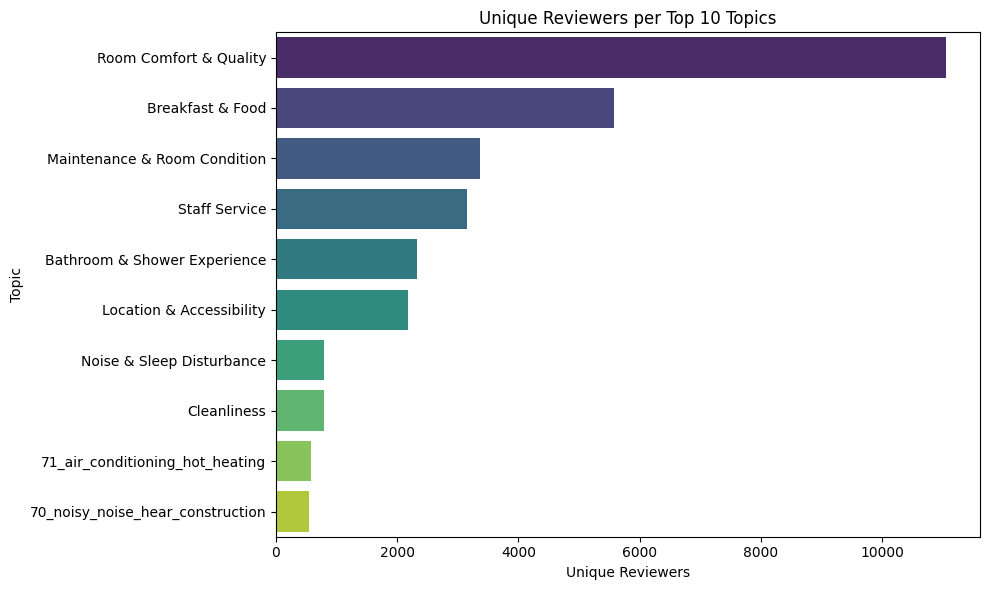

In [11]:
# Plot intertopic distance map

fig_intertopic = BERT_model.visualize_topics(custom_labels=True)
fig_intertopic.show()

# Plot top 10 topic word score barchart
fig_barchart = BERT_model.visualize_barchart(top_n_topics=10, n_words=10, custom_labels=True)
fig_barchart.show()


# Plot Unique Reviewers per Topic for top 10 topics
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate unique reviewers per topic, excluding outliers (-1)
top_inf = (
    doc_inf[doc_inf['Topic'] != -1]
    .groupby("Semantic_Label")
    .agg(Unique_Person_Count=("Person_id", "nunique"))
    .reset_index()
    .sort_values("Unique_Person_Count", ascending=False)
    .head(10) 
)

fig, ax = plt.subplots(figsize=(10, max(6, len(top_inf) * 0.4)))

sns.barplot(
    x="Unique_Person_Count", 
    y="Semantic_Label", 
    data=top_inf, 
    ax=ax, 
    palette="viridis"
)
ax.set(
    xlabel="Unique Reviewers", 
    ylabel="Topic", 
    title="Unique Reviewers per Top 10 Topics"
)

fig.tight_layout()
plt.show()


# Plot Hierarchical Dendrogram
fig_hierarchy = BERT_model.visualize_hierarchy(custom_labels=True)
fig_hierarchy.show()

## 10. Manually merge topics
After running the merge, re-run the get_topic_info() and doc_inf cells (step number 8 in the pipeline) to update the dataframes and visualisations with the new consolidated counts. Then run the cell above again to get updated visualisation charts.

In [12]:
# Uncomment if needed
'''
# Initialise empty lists
Topics_to_merge = []
merge_list = []

print("Manual Topic Merger:")
print("Enter the Topic IDs you want to combine (e.g., enter 9, then 10).")
print("Press 'm' to save that group and start a new one, or 'q' to finish and apply.")

while True:
    print(f"\nCurrent group being built: {merge_list}")
    topic_input = input("Enter Topic ID, 'm' to group, or 'q' to quit: ").strip().lower()
    
    if topic_input == 'q':
        break
    elif topic_input == 'm':
        if len(merge_list) > 1:
            Topics_to_merge.append(list(merge_list))
            print(f"Added group {merge_list} to merge queue.")
        else:
            print("Error: A merge group needs at least two IDs!")
        merge_list = []
    else:
        try:
            topic_id = int(topic_input)
            merge_list.append(topic_id)
        except ValueError:
            print("Invalid input. Please enter a number, 'm', or 'q'.")

# Apply the merge if we have groups
if len(Topics_to_merge) > 0:
    print(f"\nFinal list of merges to apply: {Topics_to_merge}")
    BERT_model.merge_topics(docs, topics_to_merge=Topics_to_merge)
    print("Success: Topics merged. You should now re-run your visualization cells.")
else:
    print("\nNo merges were performed.")
'''

'\n# Initialise empty lists\nTopics_to_merge = []\nmerge_list = []\n\nprint("Manual Topic Merger:")\nprint("Enter the Topic IDs you want to combine (e.g., enter 9, then 10).")\nprint("Press \'m\' to save that group and start a new one, or \'q\' to finish and apply.")\n\nwhile True:\n    print(f"\nCurrent group being built: {merge_list}")\n    topic_input = input("Enter Topic ID, \'m\' to group, or \'q\' to quit: ").strip().lower()\n\n    if topic_input == \'q\':\n        break\n    elif topic_input == \'m\':\n        if len(merge_list) > 1:\n            Topics_to_merge.append(list(merge_list))\n            print(f"Added group {merge_list} to merge queue.")\n        else:\n            print("Error: A merge group needs at least two IDs!")\n        merge_list = []\n    else:\n        try:\n            topic_id = int(topic_input)\n            merge_list.append(topic_id)\n        except ValueError:\n            print("Invalid input. Please enter a number, \'m\', or \'q\'.")\n\n# Apply the m

## 10. Multilingual RoBERTa Sentiment

`cardiffnlp/twitter-xlm-roberta-base-sentiment` is fine-tuned on 124M multilingual tweets
and covers negative / neutral / positive classes across the 6 languages in this dataset.

In [ ]:
from transformers import pipeline
from tqdm import tqdm

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model      = "cardiffnlp/twitter-xlm-roberta-base-sentiment",
    truncation = True,
    max_length = 64,  # Changed from 128 to 64 to save memory, adjust if you have GPU resources. No fragments should be longer than 64 tokens after our splitting anyway
    device     = -1 
)

label_map = {"negative": -1, "neutral": 0, "positive": 1}
batch_size = 32 # Can be increased if you have GPU resources, keep small on CPU to avoid memory issues
all_results = []

print(f"Running sentiment on {len(docs):,} fragments...")

for i in tqdm(range(0, len(docs), batch_size), desc="Scoring"):
    batch_docs = docs[i : i + batch_size]
    batch_results = sentiment_pipeline(batch_docs)
    all_results.extend(batch_results)

doc_inf["Sentiment_Label"] = [s['label'] for s in all_results]
doc_inf["Sentiment_Score"] = [label_map.get(s['label'], 0) * s['score'] for s in all_results]

doc_inf.to_csv(f"BERTModelRawOutputs/{Name}_Document_Info.csv", index=False)
print("Sentiment analysis complete.")
doc_inf[["Document", "Semantic_Label", "Hotel_Name", "Sentiment_Label", "Sentiment_Score"]].head(10)